In [7]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
data_root = Path('/astrum/home/hpchzy/code/data/')
date_base = '20260423'



hostname = 'camd9554n2'
# hostname = 'cgnr6760pn2'
# hostname = 'c920bn3'

# kernel = "jacobi2d5p"
kernel = "tl_f90_cg_calc_w"

data_path = data_root / f'{date_base}/{hostname}/output'

freq_dict = {'camd9554n2': 3.1, 'cgnr6760pn2': 2.2, 'c920bn3': 2.9}


# Filt data

,idx,sim_cdf,wasserstein,%wasserstein,cdf
0,0,2544,21,0.008323,0.000
1,1,2913,-2105,-0.419490,0.001
2,2,3293,-2125,-0.392211,0.002
3,3,3672,-2036,-0.356692,0.003
4,4,4007,-1931,-0.325194,0.004
...,...,...,...,...,...
996,996,16689,475,0.029296,0.996
997,997,16906,331,0.019970,0.997
998,998,17105,220,0.013029,0.998
999,999,17394,229,0.013341,0.999


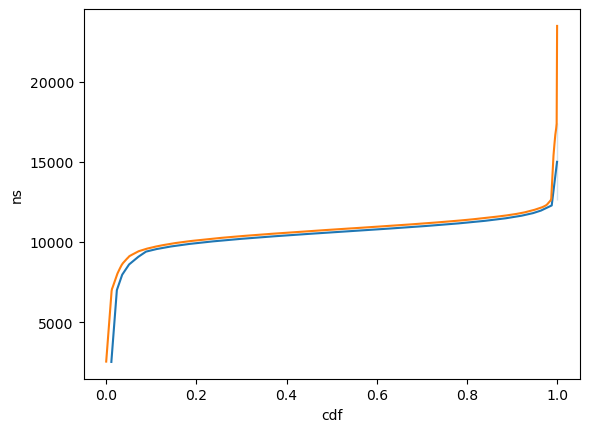

In [9]:
iarr = 1024
timer = 'cgt'

filt_folder_path = data_path / f'{kernel}{iarr}n100t_{timer}_{hostname}_filt'

tm_hist_df = pd.read_csv(filt_folder_path / 'tm_hist.csv', header=None)
tm_hist_df.columns = ['ns', 'pr']
tm_hist_df['cdf'] = tm_hist_df['pr'].cumsum()
# tm_hist_df = tm_hist_df[tm_hist_df['cdf'] <= 0.995]
tm_hist_df

sim_hist_df = pd.read_csv(filt_folder_path / 'sim_cdf.csv', header=None)
sim_hist_df.columns = ['idx','sim_cdf', 'wasserstein', '%wasserstein']
sim_hist_df['cdf'] = sim_hist_df['idx'] / sim_hist_df.index.max()
# sim_hist_df = sim_hist_df[sim_hist_df['cdf'] <= 0.995]
sim_hist_df

sns.lineplot(data=tm_hist_df, x='cdf', y='ns')
sns.lineplot(data=sim_hist_df, x='cdf', y='sim_cdf')
sim_hist_df

# Raw data

# Raw data

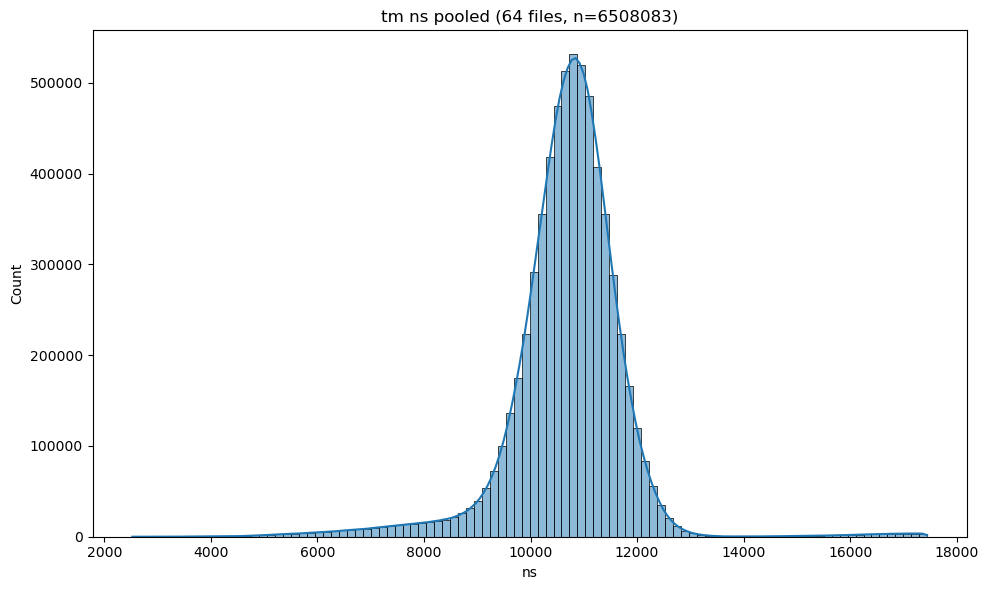

In [10]:
# pd.options.plotting.backend = 'plotly'

iarr = 1024
timer = 'cgt'

filt_folder_path = data_path / f'{kernel}{iarr}n100t_{timer}_{hostname}_filt'
tm_folder_path = data_path / f'{kernel}{iarr}n100t_{timer}_{hostname}'
tf_folder_path = data_path / f'{kernel}{iarr}n100t_{timer}_{hostname}_tf'


import seaborn as sns
import matplotlib.pyplot as plt

tm_list = sorted(tm_folder_path.iterdir())
parts = []
for file_idx, path in enumerate(tm_list):
    d = pd.read_csv(path, header=None, names=["rank", "ns"])
    d["file_idx"] = file_idx
    parts.append(d)
tm_all = pd.concat(parts, ignore_index=True)

quantile = np.quantile(tm_all['ns'], 0.995)
tm_all = tm_all[tm_all['ns'] < quantile]

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=tm_all, x="ns", bins=100, kde=True, ax=ax)
ax.set_title(f"tm ns pooled ({len(tm_list)} files, n={len(tm_all)})")
plt.tight_layout()
plt.show()

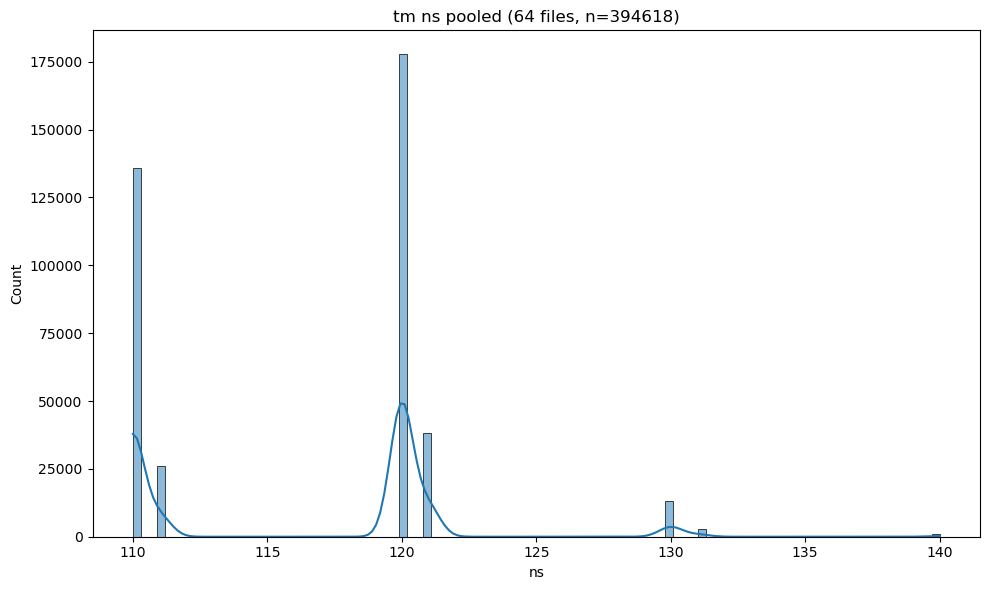

In [11]:
# pd.options.plotting.backend = 'plotly'

iarr = 64
timer = 'cgt'

filt_folder_path = data_path / f'{kernel}{iarr}n100t_{timer}_{hostname}_filt'
tm_folder_path = data_path / f'{kernel}{iarr}n100t_{timer}_{hostname}'
tf_folder_path = data_path / f'{kernel}{iarr}n100t_{timer}_{hostname}_tf'


import seaborn as sns
import matplotlib.pyplot as plt

tm_list = sorted(tm_folder_path.iterdir())
parts = []
for file_idx, path in enumerate(tm_list):
    d = pd.read_csv(path, header=None, names=["rank", "ns"])
    d["file_idx"] = file_idx
    parts.append(d)
tm_all = pd.concat(parts, ignore_index=True)

quantile = np.quantile(tm_all['ns'], 0.995)
tm_all = tm_all[tm_all['ns'] < quantile]

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=tm_all, x="ns", bins=100, kde=True, ax=ax)
ax.set_title(f"tm ns pooled ({len(tm_list)} files, n={len(tm_all)})")
plt.tight_layout()
plt.show()

In [12]:
tm_df.plot.kde()

NameError: name 'tm_df' is not defined